<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<h2>K-means and hierarchical clustering</h2>
<h3>Segmenting customers data in a mall based on their annual income and spending scores using K-means and hierarchical clustering</h3>
© Mike Bwisa M - Unsupervised Learning.
</div>

## Objectives

* Find the optimal number of clusters for a k-means clustering model.
* Apply the Kmeans clustering algorithm and evaluate its quality.
* Find the optimal number of clusters using hierachical clustering.
* Implement agglomerative hierarchical clustering.

## Introduction

The dataset contains information about mall customers, including their gender, age, annual income (in thousands of dollars), and spending score. Each row in the dataset represents a unique customer, identified by a CustomerID. The data was collected from a survey for marketing or customer segmentation purposes.

The primary objective of this analysis is to segment the customers based on their **annual income and spending scores** using K-means and hierarchical clustering. We aim to identify distinct groups of customers with similar spending behaviours and income levels. This segmentation can help in targeted marketing strategies, understanding customer preferences, and improving overall customer satisfaction and retention.

⚠️**Note**: This notebook is running Python version 3.11.14.

In [2]:
import pandas as pd
data = pd.read_csv('https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Data/unsupervised_sprint/mall_customers.csv', index_col=0)
data

,Genre,Age,Annual_Income_(k$),Spending_Score
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
...,...,...,...,...
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74


In [3]:
data.describe()

,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


## EDA
### Spending score

The `Spending_Score` is a number from 1 - 99.

### Total number of observations in this dataset 
200

### Check if the data contains any null values 
Bcause missing values can disrupt the modelling process by causing errors or biases in our analysis.

In [5]:
# Returns the count of missing values for each column
data.isnull().sum()

Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64

Our dataset contains no null values.

### Let's visualise the relationship between this pair(**annual income and spending score**). 
Since we are interested in segmenting our customers based on their **annual income and spending score**, let's visualise the relationship between this pair.

Generate a scatter plot showing the relationship between annual income and spending score for each customer in the dataset.

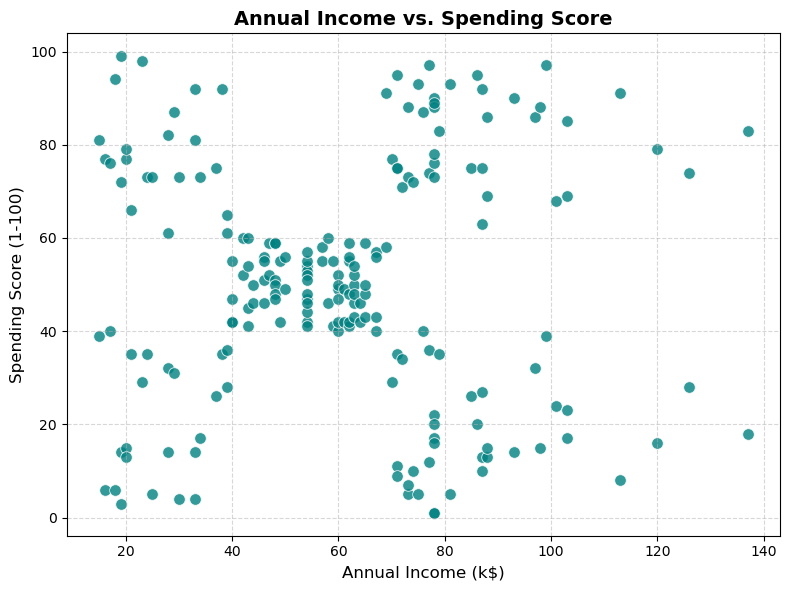

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=data, 
    x='Annual_Income_(k$)', 
    y='Spending_Score', 
    s=70, 
    color='teal', 
    alpha=0.8
) 

plt.title('Annual Income vs. Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### What insights can be inferred from the scatter plot?

* There are visible clusters forming, particularly in the center of the plot.

When plotting Annual Income against Spending Score for the Mall Customers dataset, 5 distinct, natural groupings (clusters) emerge on the 2D plane:

Center Cluster: High concentration of average earners with moderate spending scores (around $40k–$60k income, 40–60 spending score).

Top-Left: Low income, high spending score.

Bottom-Left: Low income, low spending score.

Top-Right: High income, high spending score.

Bottom-Right: High income, low spending score.

The data forms clear groups rather than a uniform or random distribution

### Scaling our data
Before continuing our analysis, we need to scale our data to prevent attributes with larger magnitudes from dominating the distance calculations.

* Fit the MinMaxScaler on numeric data because the MinMaxScaler only works with numerical data(Annual_Income_(k$), Spending_Score).

In [16]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

# Select only the relevant numerical columns
X = data[['Annual_Income_(k$)', 'Spending_Score']]
X_scaled = ms.fit_transform(X)

### Cluster analysis

Let's initiate our cluster analysis by selecting the features for segmentation. Given our focus on customer segmentation using their annual income and spending score, we'll designate the `Annual_Income_(k$)` and `Spending_Score` columns as the features for clustering, assigning them to the variable `X`.

Following feature selection, let's scale our data using the MinMaxScaler in the previous scaling data and implement the K-Means clustering algorithm on the scaled dataset, opting for **5** clusters based on an initial analysis of our scatter plot.


#### Display the coordinates of the centroids representing the clusters identified by the algorithm?

* **`print(kmeans.cluster_centers_)`**


In [18]:
from sklearn.cluster import KMeans

# 3. Fit K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

# 4. Display the cluster centroids
print(kmeans.cluster_centers_)

[[0.32695811 0.49533888]
 [0.58638083 0.82783883]
 [0.08792846 0.79962894]
 [0.59631148 0.16921769]
 [0.08792846 0.19619666]]


### Methods we can use to determine the optimal number of clusters
To build an accurate model, there are methods we can use to determine the optimal number of clusters to employ in our analysis.

#### Within-cluster variation 
- Measured by the Within-Cluster Sum of Squares (WCSS / Inertia). The Elbow Method plots WCSS against values of $K$ to find the point where adding more clusters yields diminishing returns in variance reduction.
#### Between-cluster variation
- Evaluates how well-separated distinct clusters are from each other. High between-cluster variance combined with low within-cluster variance indicates optimal clustering.
#### The CH index
- Also known as the Variance Ratio Criterion, this index explicitly calculates the ratio of between-cluster dispersion to within-cluster dispersion. Higher CH index values indicate better-defined, more distinct clusters.

### Optimal K value - Elbow method with WCSS

Let's determine the optimal k value. Use the `Elbow method`, with `WCSS`, to find the best K value for our dataset.

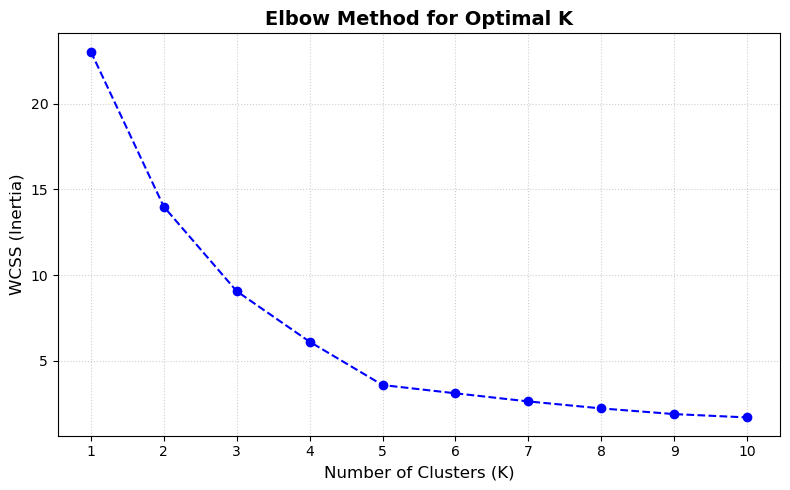

K = 1: WCSS = 23.0407
K = 2: WCSS = 13.9935
K = 3: WCSS = 9.0590
K = 4: WCSS = 6.1103
K = 5: WCSS = 3.5831
K = 6: WCSS = 3.1003
K = 7: WCSS = 2.6261
K = 8: WCSS = 2.2188
K = 9: WCSS = 1.8873
K = 10: WCSS = 1.6924


In [21]:
# 2. Compute WCSS (inertia) for k = 1 to 10
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Print WCSS values
for i, w in enumerate(wcss, 1):
    print(f"K = {i}: WCSS = {w:.4f}")

Based on the elbow method plot, the best K value for our data is 

##### Optimal K Value: 5 (5 clusters)

### Silhouette score
Let's evaluate the model's quality by computing its silhouette score.

In [25]:
from sklearn.metrics import silhouette_score

# 2. Fit K-Means with K = 5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score for K=5: {score:.4f}")

Silhouette Score for K=5: 0.5595


Based on the results, the silhouette score for a k-means model with k=5
##### is: 0.559

### Silhouette score
* The silhouette score is good because it is greater than 0 and relatively close to 1.
#### Explanation:
The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. Its values strictly range between -1 and +1:

Close to +1: Indicates that the sample is far away from neighboring clusters and well-matched to its assigned cluster (high cluster cohesion and clear separation).

Around 0: Indicates that the sample is on or very close to the decision boundary between two neighboring clusters.

Close to -1: Indicates that the sample might have been assigned to the wrong cluster.

### Next steps

The next appropriate step after determining that the silhouette score for the optimal number of clusters, determined by the elbow method.
To Use the silhouette score as input into decision-making when evaluating other clustering algorithms.

### Explanation
When both the Elbow method and Silhouette analysis indicate that K-Means fails to achieve a satisfactory partition for a chosen $K$, it often means the underlying data does not conform to K-Means' fundamental assumptions (such as spherical, similarly-sized clusters).

In practice, the appropriate next step is to test alternative clustering paradigms—such as Hierarchical Clustering (agglomerative/divisive), DBSCAN (density-based), or Gaussian Mixture Models (probabilistic)—and use the silhouette score as a baseline benchmark to compare performance across these different model architectures.

### Hierarchical clustering
Hierarchical clustering could be a natural next step for further analysis, especially considering the presence of the outliers and the potentially uneven cluster shapes observed in the KMeans model results. Hierarchical clustering can offer insights into the hierarchical structure of the data, potentially capturing nuances that KMeans might overlook.

#### key difference between KMeans and Hierarchical clustering algorithms:

* Hierarchical clustering does not require the number of clusters to be predefined. It produces a hierarchical tree of clusters, and the number of clusters can be determined after the clustering process, whereas KMeans requires the number of clusters (K) to be specified in advance.

### Dendrogram 

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/mcq_dendrogram.jpeg"  style="width:400px";/>
</div>

#### The most appropriate number of clusters is 2.

##### Explanation

To determine the number of clusters from a dendrogram:

Draw a horizontal line across the dendrogram at the largest vertical distance (the biggest jump in linkage distance) before the final merge.
Count the number of vertical branches that the line intersects.

In your dendrogram:

The largest gap occurs just before the final merge at approximately 0.58–0.65 on the y-axis.
A horizontal cut through this gap intersects 2 main branches.

### Agglomerative clustering 

Agglomerative clustering on the scaled data, **based on 5 clusters**, using the `AgglomerativeClustering` class from sklearn and print the resulting cluster labels.

In [26]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = cluster.fit_predict(X_scaled)
labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 1, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 2, 0, 2, 0,
       1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0])

### visualising the clusters

After creating a scatter plot visualising the clusters based on the cluster labels in Agglomerative clustering above, we calculated and printed the mean values of each feature within each cluster, providing insights into the characteristics of each cluster. See image below.

#  

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://raw.githubusercontent.com/Explore-AI/Pictures/master/sklearn_MCQ_image.png"  style="width:1000px";/>
</div>

### Cluster 3
* Cluster 3 represents customers with average annual income and spending scores.



In [ ]:
#Your code here

### Cluster 2

* Customers in Cluster 2, on average, earn more annually compared to the average earnings of all customers in the dataset.


### Visualise the number of data points per cluster using a bar chart

In order to understand the distribution of data points among different clusters we can visualise the number of data points per cluster using a bar chart.

Generate a bar chart that displays the number of data points in each cluster for both our features. 

/var/folders/tp/cdxyq2g15m15qtssv83_vs6m0000gp/T/ipykernel_29761/504048615.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


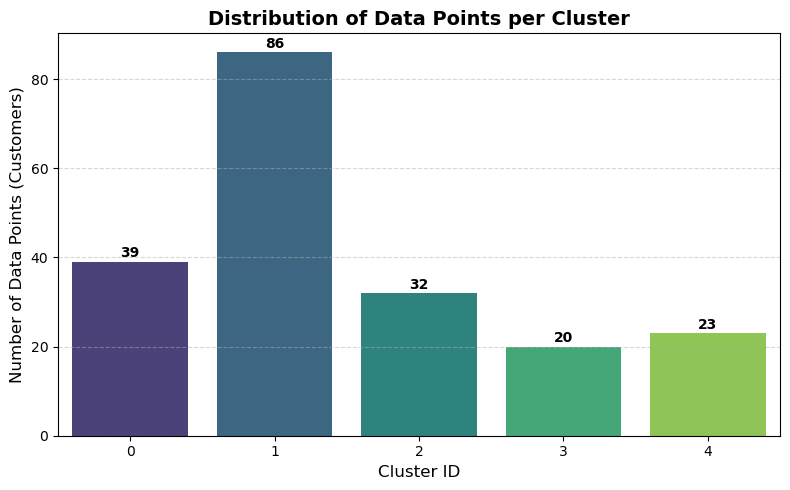

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ensure cluster labels are stored in the DataFrame
data['cluster'] = cluster.fit_predict(X_scaled)

# 2. Count the number of data points in each cluster
cluster_counts = data['cluster'].value_counts().sort_index()

# 3. Plot the distribution
plt.figure(figsize=(8, 5))
sns.barplot(
    x=cluster_counts.index, 
    y=cluster_counts.values, 
    palette='viridis'
)

plt.title('Distribution of Data Points per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Data Points (Customers)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display exact counts on top of each bar
for index, count in enumerate(cluster_counts.values):
    plt.text(index, count + 1, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

From the distribution of data points among clusters in our resulting clustering model, we can infere that:

#### The clustering model has successfully separated the data into distinct and balanced clusters.

### Davies-Bouldin Index (DBI)

When evaluating the quality of clustering using the `Davies-Bouldin Index (DBI)`,
* A lower DBI value indicates better clustering, where clusters are more compact and well-separated.

#### Explanation
The Davies-Bouldin Index (DBI) measures the average similarity ratio of each cluster with its most similar cluster. Similarity is calculated as a ratio of:

Within-cluster dispersion (distance between points and their centroid): We want this to be as low as possible (tight, compact clusters).

Between-cluster separation (distance between centroids): We want this to be as high as possible (well-separated clusters).

Because the DBI calculates dispersion divided by separation, lower values (closer to 0) represent superior clustering quality with tighter clusters and greater distance between different groups.


In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler

# 1. Select features and scale
X = data[['Annual_Income_(k$)', 'Spending_Score']]
ms = MinMaxScaler()
X_scaled = ms.fit_transform(X)

# 2. Fit K-Means (e.g., K = 5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 3. Calculate Davies-Bouldin Index
dbi_score = davies_bouldin_score(X_scaled, cluster_labels)
print(f"Davies-Bouldin Index for K=5: {dbi_score:.4f}")

Davies-Bouldin Index for K=5: 0.5678


### Hierarchical clustering - distance between any two points

The criterion measures the shortest distance between any two points in the two clusters being merged in hierarchical clustering?

#### Explanation
- Single Linkage: Measures the minimum distance (shortest distance) between any single point in cluster $A$ and any single point in cluster $B$:  $$d(A, B) = \min \{ d(x, y) : x \in A, y \in B \}$$
- Complete Linkage: Measures the maximum distance (furthest distance) between any point in cluster $A$ and any point in cluster $B$.
- Average Linkage: Calculates the average distance between all pairs of points in cluster $A$ and cluster $B$.
- Ward Linkage: Minimizes the total within-cluster variance (sum of squared distances from the centroid) when merging two clusters.

### Refitmodel, Performing further EDA and include additional relevant features

Next step to take based on the silhouette scores for our KMeans clustering and Hierarchical clustering models, along with the distribution of data points in our clusters?

#### Steps:

* Refit models with different hyperparameters: Adjusting parameters such as linkage criteria (ward, complete, average), distance metrics (euclidean, manhattan), or initialization methods can yield better separation and cohesion.

* Perform further exploratory data analysis (EDA): Deepening EDA on the individual clusters helps uncover why certain data points group together, identifying skewness, outliers, or overlapping features that may distort cluster boundaries.

* Include additional relevant features: Introducing additional meaningful features (e.g., customer age, transaction frequency, or loyalty tenure) enriches the feature space, giving the algorithms more signal to form distinct, actionable segments.

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="COPYRIGHT_MIKE_BWISA_MWASAME-01.jpg"  style="display: block; margin-left: auto; margin-right: auto;";/>
</div>